# 08 – Class Balancing: Oversampling y Undersampling

**Proyecto:** Encuesta Permanente de Empleo Nacional (EPEN) 2024  
**Target:** `target_subempleo_horas` — 1 = trabajador con voluntad y disponibilidad para trabajar más horas

## Objetivo

Este notebook evalúa si técnicas de rebalanceo de clases mejoran la detección de trabajadores con subempleo por insuficiencia de horas (clase positiva = 1).

La técnica `class_weight="balanced"` ya fue evaluada en `07_modelling/`. Aquí se prueban técnicas de **remuestreo** (RandomOverSampler y RandomUnderSampler) como análisis complementario.

> ⚠️ El rebalanceo se aplica **únicamente** al conjunto de entrenamiento (`X_train`, `y_train`). El conjunto de prueba **no se modifica**.

In [2]:
%pip install pandas matplotlib seaborn imblearn pathlib


   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   -------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [4]:
SELECTED_DIR = Path("../data/selected")
RESULTS_DIR  = Path("../data/results")
MODELS_DIR   = Path("../models")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

def _load(path):
    if not path.exists():
        raise FileNotFoundError(
            f"Archivo no encontrado: {path}\n"
            "Primero debe ejecutarse 05_feature_selection/selected_variables.ipynb"
        )
    return pd.read_csv(path)

X_train = _load(SELECTED_DIR / "X_train_selected.csv")
X_test  = _load(SELECTED_DIR / "X_test_selected.csv")
y_train = _load(SELECTED_DIR / "y_train_selected.csv").squeeze()
y_test  = _load(SELECTED_DIR / "y_test_selected.csv").squeeze()

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")

X_train : (19243, 33)  |  y_train : (19243,)
X_test  : (4811, 33)   |  y_test  : (4811,)


In [5]:
# Mismas columnas en train y test
assert list(X_train.columns) == list(X_test.columns), \
    "X_train y X_test no tienen las mismas columnas"

# Solo 0 y 1 en target
for name, s in [("y_train", y_train), ("y_test", y_test)]:
    vals = set(s.unique())
    assert vals <= {0, 1}, f"{name} contiene valores fuera de {{0, 1}}: {vals}"

# Sin leakage
LEAKAGE_COLS = ["P209H", "C333", "C334", "target_subempleo_horas"]
for col in LEAKAGE_COLS:
    assert col not in X_train.columns, f"Leakage en X_train: {col}"
    assert col not in X_test.columns,  f"Leakage en X_test: {col}"

# Sin nulos
assert X_train.isnull().sum().sum() == 0, "X_train tiene nulos"
assert X_test.isnull().sum().sum()  == 0, "X_test tiene nulos"
assert y_train.isnull().sum()       == 0, "y_train tiene nulos"
assert y_test.isnull().sum()        == 0, "y_test tiene nulos"

print("Validaciones OK")

Validaciones OK



y_train:
  Clase 0: 14,451  (75.1%)
  Clase 1:  4,792  (24.9%)

y_test:
  Clase 0:  3,613  (75.1%)
  Clase 1:  1,198  (24.9%)


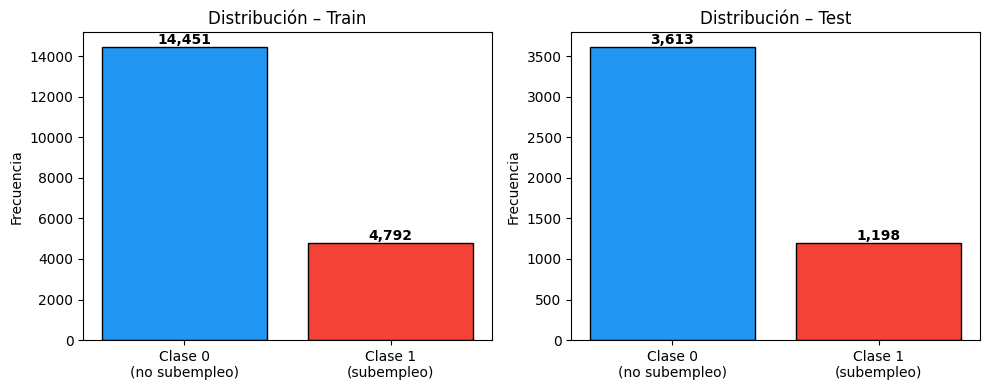

In [6]:
# 1. Distribución de clases
def show_distribution(y, name):
    counts = y.value_counts().sort_index()
    pct    = y.value_counts(normalize=True).sort_index() * 100
    print(f"\n{name}:")
    for cls in counts.index:
        print(f"  Clase {cls}: {counts[cls]:>6,}  ({pct[cls]:.1f}%)")

show_distribution(y_train, "y_train")
show_distribution(y_test,  "y_test")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y, title) in zip(axes, [(y_train, "Train"), (y_test, "Test")]):
    counts = y.value_counts().sort_index()
    ax.bar(
        ["Clase 0\n(no subempleo)", "Clase 1\n(subempleo)"],
        counts.values,
        color=["#2196F3", "#F44336"],
        edgecolor="black",
    )
    ax.set_title(f"Distribución – {title}")
    ax.set_ylabel("Frecuencia")
    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.max() * 0.01, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
# 2. Función de evaluación

def evaluate_model(model_name, model_type, balancing_strategy, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_pred  = pipeline.predict(X_te)
    y_proba = pipeline.predict_proba(X_te)[:, 1] if hasattr(pipeline, "predict_proba") else None

    print(f"\n{'='*60}")
    print(f"Modelo: {model_name}  |  Estrategia: {balancing_strategy}")
    print("=" * 60)
    print(classification_report(y_te, y_pred, target_names=["Clase 0", "Clase 1"]))

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
    disp.plot(colorbar=False)
    plt.title(f"Conf. Matrix – {model_name} ({balancing_strategy})")
    plt.tight_layout()
    plt.show()

    roc_auc = roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan
    return {
        "model_name":         model_name,
        "model_type":         model_type,
        "balancing_strategy": balancing_strategy,
        "accuracy":           accuracy_score(y_te, y_pred),
        "precision_0":        precision_score(y_te, y_pred, pos_label=0, zero_division=0),
        "recall_0":           recall_score(y_te, y_pred,    pos_label=0, zero_division=0),
        "f1_0":               f1_score(y_te, y_pred,        pos_label=0, zero_division=0),
        "precision_1":        precision_score(y_te, y_pred, pos_label=1, zero_division=0),
        "recall_1":           recall_score(y_te, y_pred,    pos_label=1, zero_division=0),
        "f1_1":               f1_score(y_te, y_pred,        pos_label=1, zero_division=0),
        "roc_auc":            roc_auc,
        "_pipeline":          pipeline,
        "_y_proba":           y_proba,
    }

## 3. Modelos a comparar

| Modelo | Tipo | Estrategia de rebalanceo |
|--------|------|--------------------------|
| A | Logistic Regression | Sin resampling |
| B | Logistic Regression | RandomOverSampler |
| C | Logistic Regression | RandomUnderSampler |
| D | Random Forest | Sin resampling |
| E | Random Forest | RandomOverSampler |
| F | Random Forest | RandomUnderSampler |


Modelo: LR_no_resampling  |  Estrategia: none
              precision    recall  f1-score   support

     Clase 0       0.78      0.97      0.87      3613
     Clase 1       0.68      0.19      0.30      1198

    accuracy                           0.78      4811
   macro avg       0.73      0.58      0.58      4811
weighted avg       0.76      0.78      0.73      4811



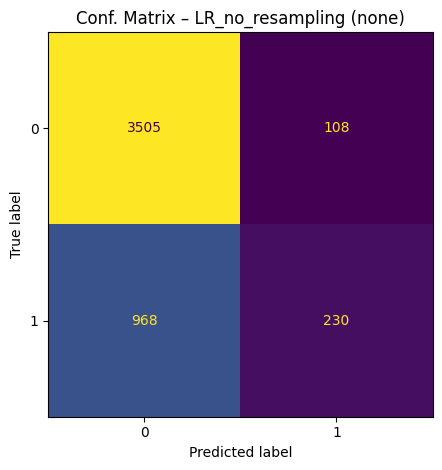


Modelo: LR_RandomOverSampler  |  Estrategia: random_over
              precision    recall  f1-score   support

     Clase 0       0.83      0.73      0.78      3613
     Clase 1       0.41      0.57      0.47      1198

    accuracy                           0.69      4811
   macro avg       0.62      0.65      0.63      4811
weighted avg       0.73      0.69      0.70      4811



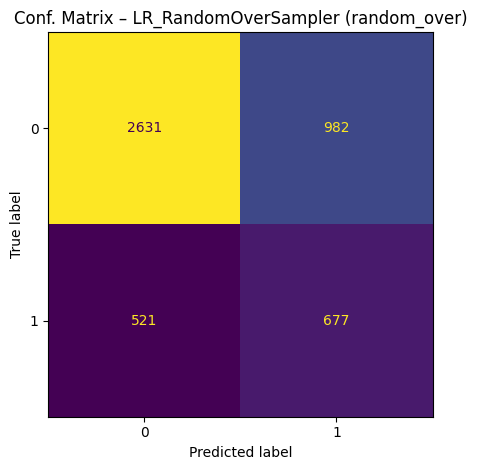


Modelo: LR_RandomUnderSampler  |  Estrategia: random_under
              precision    recall  f1-score   support

     Clase 0       0.83      0.73      0.78      3613
     Clase 1       0.41      0.56      0.47      1198

    accuracy                           0.69      4811
   macro avg       0.62      0.65      0.63      4811
weighted avg       0.73      0.69      0.70      4811



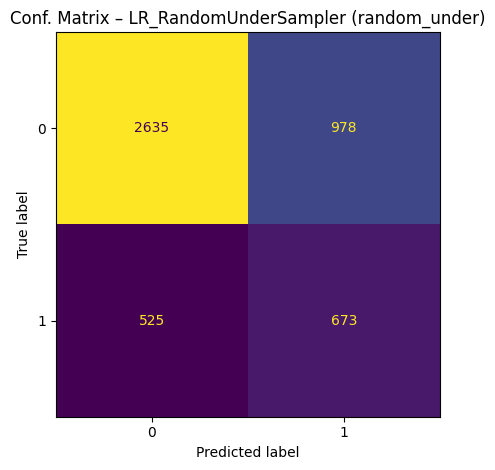


Modelo: RF_no_resampling  |  Estrategia: none
              precision    recall  f1-score   support

     Clase 0       0.79      0.95      0.86      3613
     Clase 1       0.59      0.22      0.32      1198

    accuracy                           0.77      4811
   macro avg       0.69      0.59      0.59      4811
weighted avg       0.74      0.77      0.73      4811



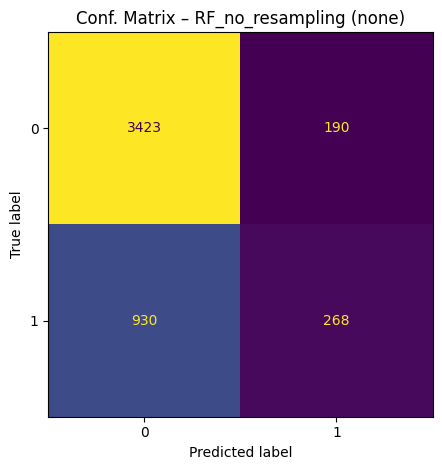


Modelo: RF_RandomOverSampler  |  Estrategia: random_over
              precision    recall  f1-score   support

     Clase 0       0.80      0.90      0.84      3613
     Clase 1       0.49      0.31      0.38      1198

    accuracy                           0.75      4811
   macro avg       0.64      0.60      0.61      4811
weighted avg       0.72      0.75      0.73      4811



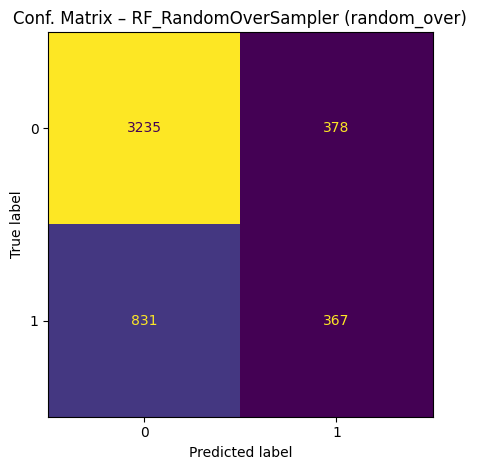


Modelo: RF_RandomUnderSampler  |  Estrategia: random_under
              precision    recall  f1-score   support

     Clase 0       0.82      0.66      0.73      3613
     Clase 1       0.35      0.55      0.43      1198

    accuracy                           0.63      4811
   macro avg       0.58      0.61      0.58      4811
weighted avg       0.70      0.63      0.65      4811



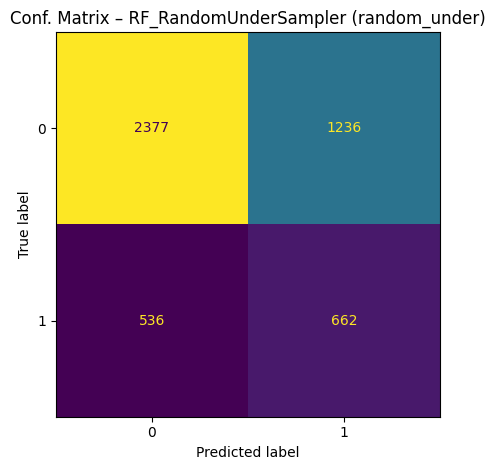


Todos los modelos entrenados y evaluados.


In [8]:
results = []

# ── A: LR sin resampling ──────────────────────────────────────────────────────
pipe_a = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=3000, random_state=42)),
])
results.append(evaluate_model(
    "LR_no_resampling", "logistic_regression", "none",
    pipe_a, X_train, y_train, X_test, y_test,
))

# ── B: LR + RandomOverSampler ─────────────────────────────────────────────────
pipe_b = ImbPipeline([
    ("scaler", StandardScaler()),
    ("ros",    RandomOverSampler(random_state=42)),
    ("clf",    LogisticRegression(max_iter=3000, random_state=42)),
])
results.append(evaluate_model(
    "LR_RandomOverSampler", "logistic_regression", "random_over",
    pipe_b, X_train, y_train, X_test, y_test,
))

# ── C: LR + RandomUnderSampler ────────────────────────────────────────────────
pipe_c = ImbPipeline([
    ("scaler", StandardScaler()),
    ("rus",    RandomUnderSampler(random_state=42)),
    ("clf",    LogisticRegression(max_iter=3000, random_state=42)),
])
results.append(evaluate_model(
    "LR_RandomUnderSampler", "logistic_regression", "random_under",
    pipe_c, X_train, y_train, X_test, y_test,
))

# ── D: RF sin resampling ──────────────────────────────────────────────────────
pipe_d = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
results.append(evaluate_model(
    "RF_no_resampling", "random_forest", "none",
    pipe_d, X_train, y_train, X_test, y_test,
))

# ── E: RF + RandomOverSampler ─────────────────────────────────────────────────
pipe_e = ImbPipeline([
    ("ros", RandomOverSampler(random_state=42)),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])
results.append(evaluate_model(
    "RF_RandomOverSampler", "random_forest", "random_over",
    pipe_e, X_train, y_train, X_test, y_test,
))

# ── F: RF + RandomUnderSampler ────────────────────────────────────────────────
pipe_f = ImbPipeline([
    ("rus", RandomUnderSampler(random_state=42)),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])
results.append(evaluate_model(
    "RF_RandomUnderSampler", "random_forest", "random_under",
    pipe_f, X_train, y_train, X_test, y_test,
))

print("\nTodos los modelos entrenados y evaluados.")

## Nota sobre SMOTE

SMOTE (*Synthetic Minority Over-sampling Technique*) puede probarse de forma **opcional**, pero debe interpretarse con cuidado en este dataset.

Las features seleccionadas pueden incluir variables **binarias o dummies** (indicadores de categoría, presencia/ausencia de una condición). SMOTE genera valores sintéticos mediante interpolación entre vecinos cercanos, lo que puede producir **valores no enteros** en variables que originalmente son binarias (p. ej., 0.43 en lugar de 0 ó 1).

**No se usa SMOTE como modelo principal** en este notebook. Si se desea explorarlo, se recomienda:

1. Verificar qué features son estrictamente binarias.
2. Considerar variantes como `SMOTENC` para variables mixtas (continuas + categóricas).
3. Comparar las métricas obtenidas con las de los modelos base antes de adoptarlo.

In [9]:
# 4. Consolidar métricas
METRIC_COLS = [
    "model_name", "model_type", "balancing_strategy",
    "accuracy", "precision_0", "recall_0", "f1_0",
    "precision_1", "recall_1", "f1_1", "roc_auc",
]

class_balancing_metrics = pd.DataFrame([
    {k: r[k] for k in METRIC_COLS} for r in results
])
class_balancing_metrics = (
    class_balancing_metrics
    .sort_values(["f1_1", "recall_1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
class_balancing_metrics.index += 1

print("Ranking (prioridad: F1-score clase 1):")
print(
    class_balancing_metrics[[
        "model_name", "balancing_strategy",
        "recall_1", "precision_1", "f1_1", "roc_auc",
    ]].to_string()
)

Ranking (prioridad: F1-score clase 1):
              model_name balancing_strategy  recall_1  precision_1      f1_1   roc_auc
1   LR_RandomOverSampler        random_over  0.565109     0.408077  0.473924  0.695862
2  LR_RandomUnderSampler       random_under  0.561770     0.407632  0.472446  0.697351
3  RF_RandomUnderSampler       random_under  0.552588     0.348788  0.427649  0.656490
4   RF_RandomOverSampler        random_over  0.306344     0.492617  0.377766  0.649862
5       RF_no_resampling               none  0.223706     0.585153  0.323671  0.655365
6       LR_no_resampling               none  0.191987     0.680473  0.299479  0.696700


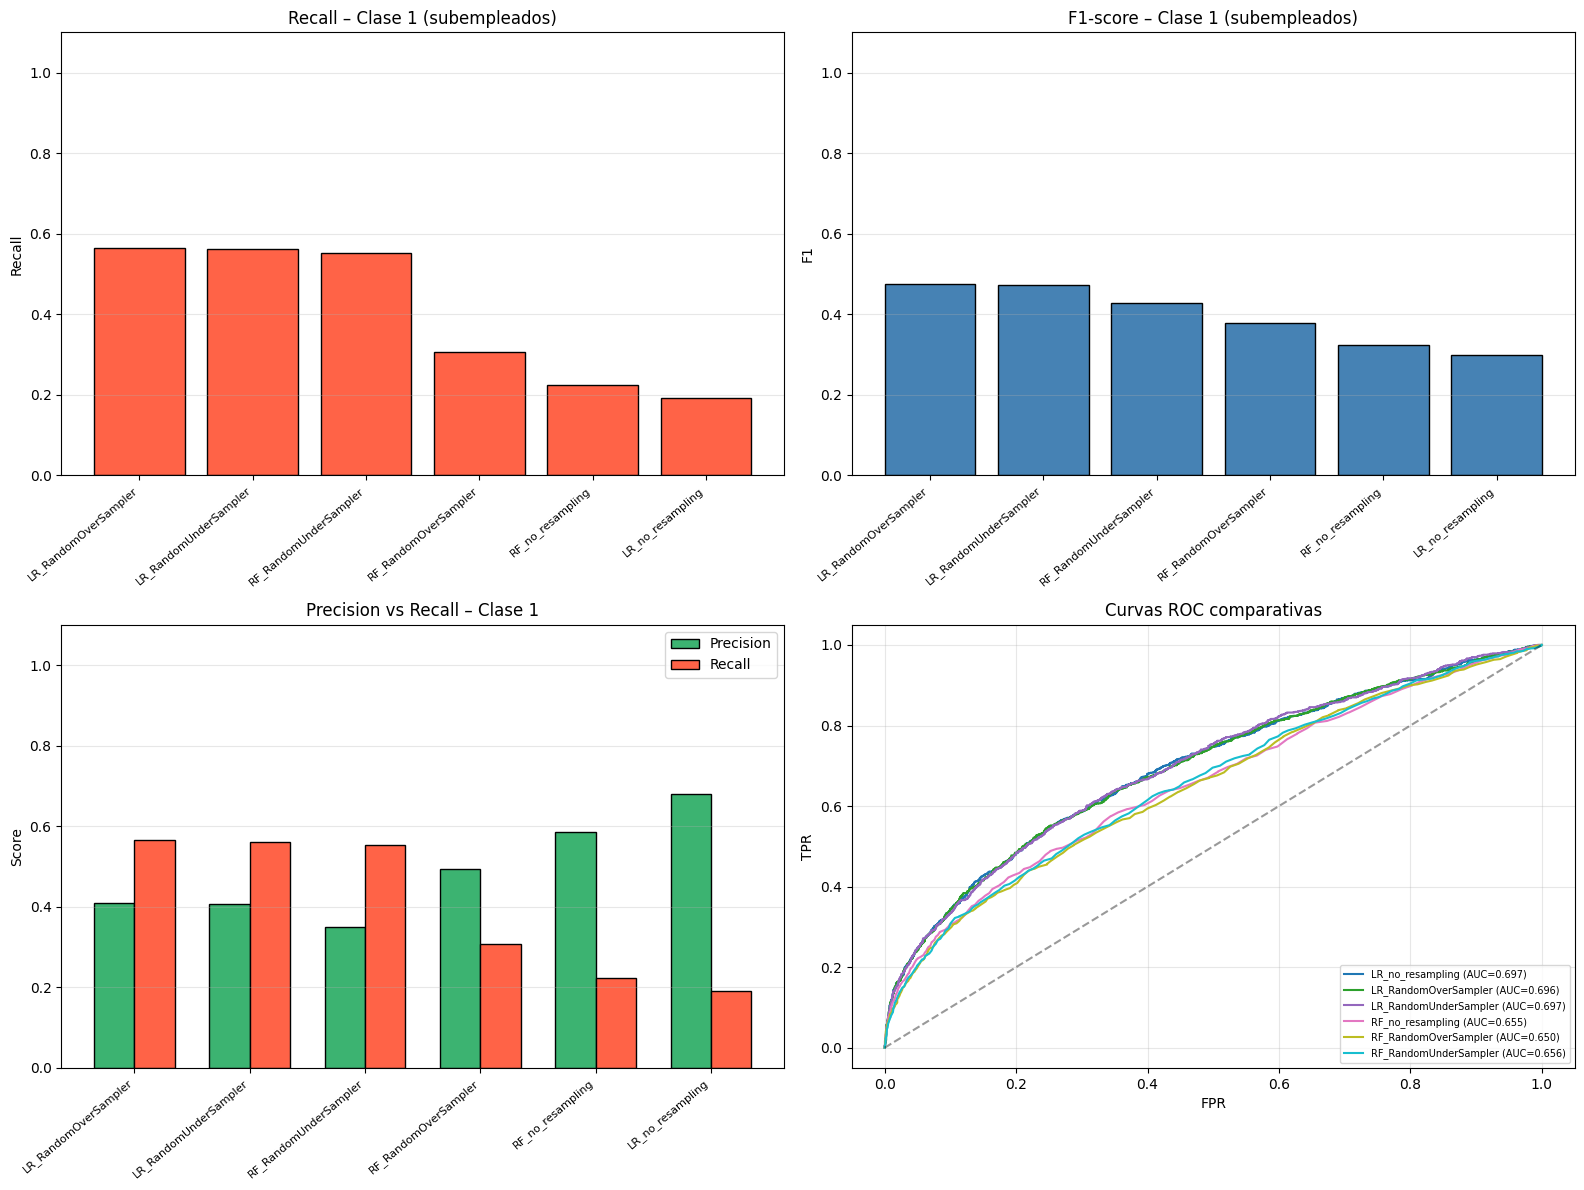

In [10]:
# 5. Comparación visual
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

names = class_balancing_metrics["model_name"]
x = np.arange(len(names))

# Panel 1: Recall clase 1
ax1 = axes[0, 0]
ax1.bar(x, class_balancing_metrics["recall_1"], color="tomato", edgecolor="black")
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=40, ha="right", fontsize=8)
ax1.set_title("Recall – Clase 1 (subempleados)")
ax1.set_ylabel("Recall")
ax1.set_ylim(0, 1.1)
ax1.grid(axis="y", alpha=0.3)

# Panel 2: F1-score clase 1
ax2 = axes[0, 1]
ax2.bar(x, class_balancing_metrics["f1_1"], color="steelblue", edgecolor="black")
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=40, ha="right", fontsize=8)
ax2.set_title("F1-score – Clase 1 (subempleados)")
ax2.set_ylabel("F1")
ax2.set_ylim(0, 1.1)
ax2.grid(axis="y", alpha=0.3)

# Panel 3: Precision vs Recall clase 1
ax3 = axes[1, 0]
w = 0.35
ax3.bar(x - w/2, class_balancing_metrics["precision_1"], width=w,
        label="Precision", color="mediumseagreen", edgecolor="black")
ax3.bar(x + w/2, class_balancing_metrics["recall_1"], width=w,
        label="Recall", color="tomato", edgecolor="black")
ax3.set_xticks(x)
ax3.set_xticklabels(names, rotation=40, ha="right", fontsize=8)
ax3.set_title("Precision vs Recall – Clase 1")
ax3.set_ylabel("Score")
ax3.set_ylim(0, 1.1)
ax3.legend()
ax3.grid(axis="y", alpha=0.3)

# Panel 4: Curvas ROC
ax4 = axes[1, 1]
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for r, color in zip(results, colors):
    if r["_y_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test, r["_y_proba"])
        ax4.plot(fpr, tpr, label=f"{r['model_name']} (AUC={r['roc_auc']:.3f})", color=color)
ax4.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax4.set_xlabel("FPR")
ax4.set_ylabel("TPR")
ax4.set_title("Curvas ROC comparativas")
ax4.legend(fontsize=7, loc="lower right")
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# 6. Guardar modelos con resampling
models_to_save = {
    "logistic_regression_ros": next(r["_pipeline"] for r in results if r["model_name"] == "LR_RandomOverSampler"),
    "logistic_regression_rus": next(r["_pipeline"] for r in results if r["model_name"] == "LR_RandomUnderSampler"),
    "random_forest_ros":       next(r["_pipeline"] for r in results if r["model_name"] == "RF_RandomOverSampler"),
    "random_forest_rus":       next(r["_pipeline"] for r in results if r["model_name"] == "RF_RandomUnderSampler"),
}

for name, model in models_to_save.items():
    path = MODELS_DIR / f"{name}.pkl"
    joblib.dump(model, path)
    print(f"Guardado: {path}")

Guardado: ..\models\logistic_regression_ros.pkl
Guardado: ..\models\logistic_regression_rus.pkl
Guardado: ..\models\random_forest_ros.pkl
Guardado: ..\models\random_forest_rus.pkl


In [12]:
# 7. Guardar resultados

# Métricas completas
metrics_path = RESULTS_DIR / "class_balancing_metrics.csv"
class_balancing_metrics.reset_index(drop=True).to_csv(metrics_path, index=False)
print(f"Guardado: {metrics_path}")

# Resumen ejecutivo
summary = class_balancing_metrics[[
    "model_name", "balancing_strategy",
    "recall_1", "precision_1", "f1_1", "roc_auc",
]].copy()
summary_path = RESULTS_DIR / "class_balancing_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"Guardado: {summary_path}")

Guardado: ..\data\results\class_balancing_metrics.csv
Guardado: ..\data\results\class_balancing_summary.csv


## Conclusiones

- El rebalanceo se aplicó **únicamente al conjunto de entrenamiento**; el conjunto de prueba mantuvo su distribución original durante toda la evaluación.
- Se compararon seis configuraciones: Logistic Regression y Random Forest, cada uno con tres estrategias (sin resampling, RandomOverSampler, RandomUnderSampler).
- El **oversampling** tiende a aumentar el recall de la clase 1 (detección de subempleados), a costa de una posible reducción en precisión.
- El **undersampling** puede mejorar el balance entre clases pero descarta información del entrenamiento, lo que puede afectar la capacidad de generalización.
- Si el rebalanceo mejora recall pero reduce mucho precision, debe evaluarse en función del objetivo del proyecto: detectar subempleo (priorizar recall) vs. evitar falsas alarmas (priorizar precision).
- Si `class_weight="balanced"` (evaluado en `07_modelling/`) logra resultados similares, puede preferirse por ser **más simple y menos invasivo**.

> ⚠️ Este notebook es un **análisis complementario**. No reemplaza automáticamente el mejor modelo identificado en `07_modelling/model_comparison.ipynb`.